# Week 2 — RFM Scoring & Customer Segmentation
**Goal:** Visually explore the RFM scores and K-Means clusters produced by `src/features.py` and `src/train.py`.  
**Input:** `data/rfm_segments.csv` — one row per customer with RFM scores, cluster label, and segment name.  
**Output:** 7 plots saved to `reports/` and a clear understanding of each customer segment.

Run cells top to bottom. Every cell has comments explaining what it does and why.

## Cell 1 — Imports and settings

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# Consistent colour palette — one colour per segment, used across all plots
SEGMENT_COLOURS = {
    'Loyal VIP'       : '#185FA5',
    'Champions'       : '#0F6E56',
    'New / Promising' : '#854F0B',
    'At Risk'         : '#993C1D',
    'Needs Attention' : '#534AB7',
    'Lost / Inactive' : '#888882',
}

ROOT    = Path('..').resolve()
RPT_DIR = ROOT / 'reports'
RPT_DIR.mkdir(exist_ok=True)

print('Imports done.')
print(f'Project root : {ROOT}')

Imports done.
Project root : C:\Users\aishw\Documents\customer_segmentation


## Cell 2 — Load data

In [2]:
df = pd.read_csv(ROOT / 'data' / 'rfm_segments.csv')

print(f'Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns : {list(df.columns)}')
print()

# Segment distribution — first thing to always check
seg_counts = df['KMeans_Segment'].value_counts()
print('Segment distribution:')
for seg, count in seg_counts.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {seg:<22} : {count:>5,}  ({pct:>5.1f}%)  {bar}')

print()
df.head(3)

Shape   : 5,796 rows × 18 columns
Columns : ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'RFM_Weighted', 'Segment', 'avg_order_value', 'purchase_freq_annual', 'lifespan_weeks', 'CLV', 'CLV_capped', 'Cluster', 'KMeans_Segment']

Segment distribution:
  New / Promising        : 2,810  ( 48.5%)  ████████████████████████
  Lost / Inactive        : 1,852  ( 32.0%)  ███████████████
  Champions              :   894  ( 15.4%)  ███████
  Loyal VIP              :   240  (  4.1%)  ██



,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,RFM_Weighted,Segment,avg_order_value,purchase_freq_annual,lifespan_weeks,CLV,CLV_capped,Cluster,KMeans_Segment
0,12347,2,8,4921.53,5,4,5,545,14,4.65,Champions,615.19125,7.243781,57.428571,4456.31,4456.31,1,Champions
1,12348,75,5,2019.40,3,4,4,344,11,3.60,Loyal Customers,403.88000,5.027624,51.714286,2030.56,2030.56,2,New / Promising
2,12349,19,4,4428.69,5,3,5,535,13,4.30,Loyal Customers,1107.17250,2.554386,81.428571,2828.15,2828.15,2,New / Promising


## Cell 3 — Segment size overview (bar chart)
How many customers are in each segment? This is the first chart a business stakeholder wants to see.

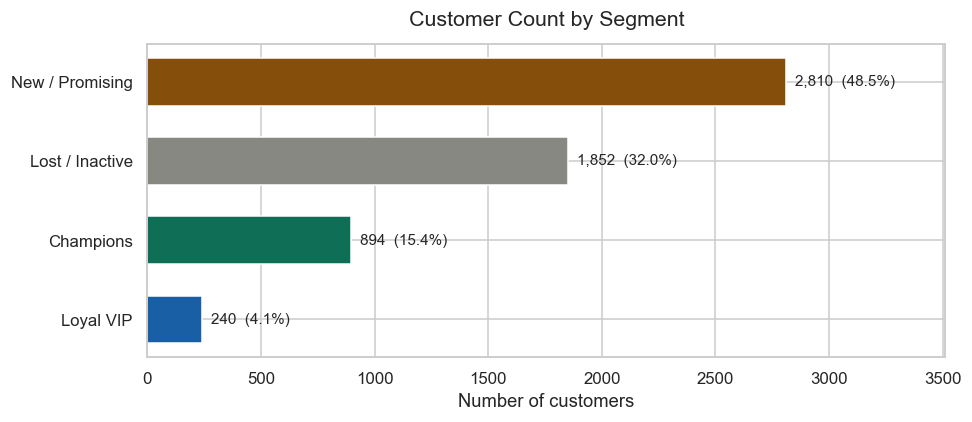

Saved → reports/plot_09_segment_sizes.png


In [3]:
seg_counts = df['KMeans_Segment'].value_counts()
colours    = [SEGMENT_COLOURS.get(s, '#888882') for s in seg_counts.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(seg_counts.index, seg_counts.values,
               color=colours, edgecolor='white', height=0.6)
ax.bar_label(bars,
             labels=[f'{v:,}  ({v/len(df)*100:.1f}%)' for v in seg_counts.values],
             padding=6, fontsize=10)

ax.set_title('Customer Count by Segment', fontsize=14, pad=12)
ax.set_xlabel('Number of customers')
ax.set_xlim(0, seg_counts.max() * 1.25)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_09_segment_sizes.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_09_segment_sizes.png')

## Cell 4 — RFM distributions per segment (box plots)
Box plots show the spread of Recency, Frequency, and Monetary within each segment.
This validates that the segments are genuinely different from each other.

What to look for:
- Boxes should NOT heavily overlap between segments
- Lost/Inactive should have high Recency (many days since purchase)
- Loyal VIP should have high Frequency and Monetary

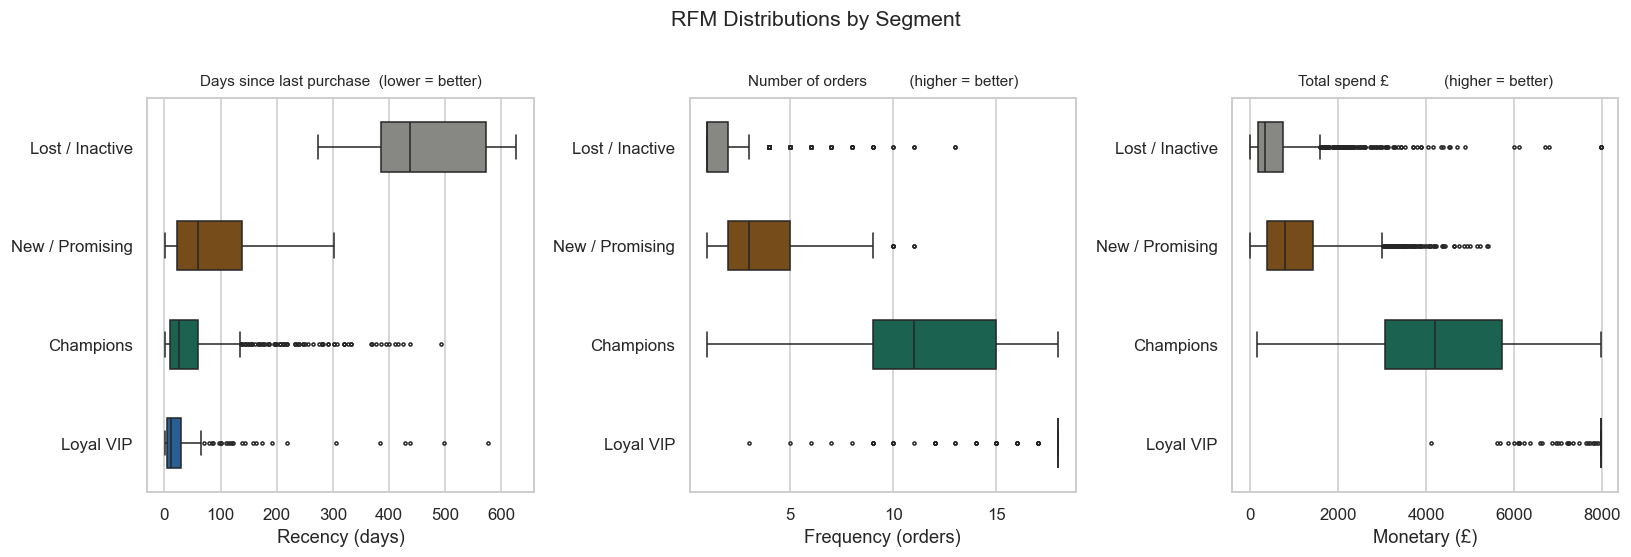

Saved → reports/plot_10_rfm_boxplots.png

Median RFM per segment:
                 Recency  Frequency  Monetary
KMeans_Segment                               
Champions           26.5       11.0    4198.2
Lost / Inactive    437.5        1.0     360.8
Loyal VIP           12.0       26.0   12061.0
New / Promising     59.0        3.0     810.9


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RFM Distributions by Segment', fontsize=14, y=1.01)

metrics = [
    ('Recency',   'Days since last purchase  (lower = better)', 'days'),
    ('Frequency', 'Number of orders          (higher = better)', 'orders'),
    ('Monetary',  'Total spend £             (higher = better)', '£'),
]

# Determine segment order by median Recency (Lost first, Champions last)
seg_order = (df.groupby('KMeans_Segment')['Recency']
               .median()
               .sort_values(ascending=False)
               .index.tolist())

for ax, (col, title, unit) in zip(axes, metrics):
    # Cap at 95th percentile so outliers don't squash the boxes
    cap = df[col].quantile(0.95)
    plot_df = df.copy()
    plot_df[col] = plot_df[col].clip(upper=cap)

    palette = {s: SEGMENT_COLOURS.get(s, '#888882') for s in seg_order}
    sns.boxplot(
        data=plot_df,
        x=col, y='KMeans_Segment',
        order=seg_order,
        palette=palette,
        width=0.5,
        fliersize=2,
        ax=ax
    )
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel(f'{col} ({unit})')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_10_rfm_boxplots.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_10_rfm_boxplots.png')

# Print median RFM per segment for quick reference
print('\nMedian RFM per segment:')
print(df.groupby('KMeans_Segment')[['Recency','Frequency','Monetary']]
        .median().round(1).to_string())

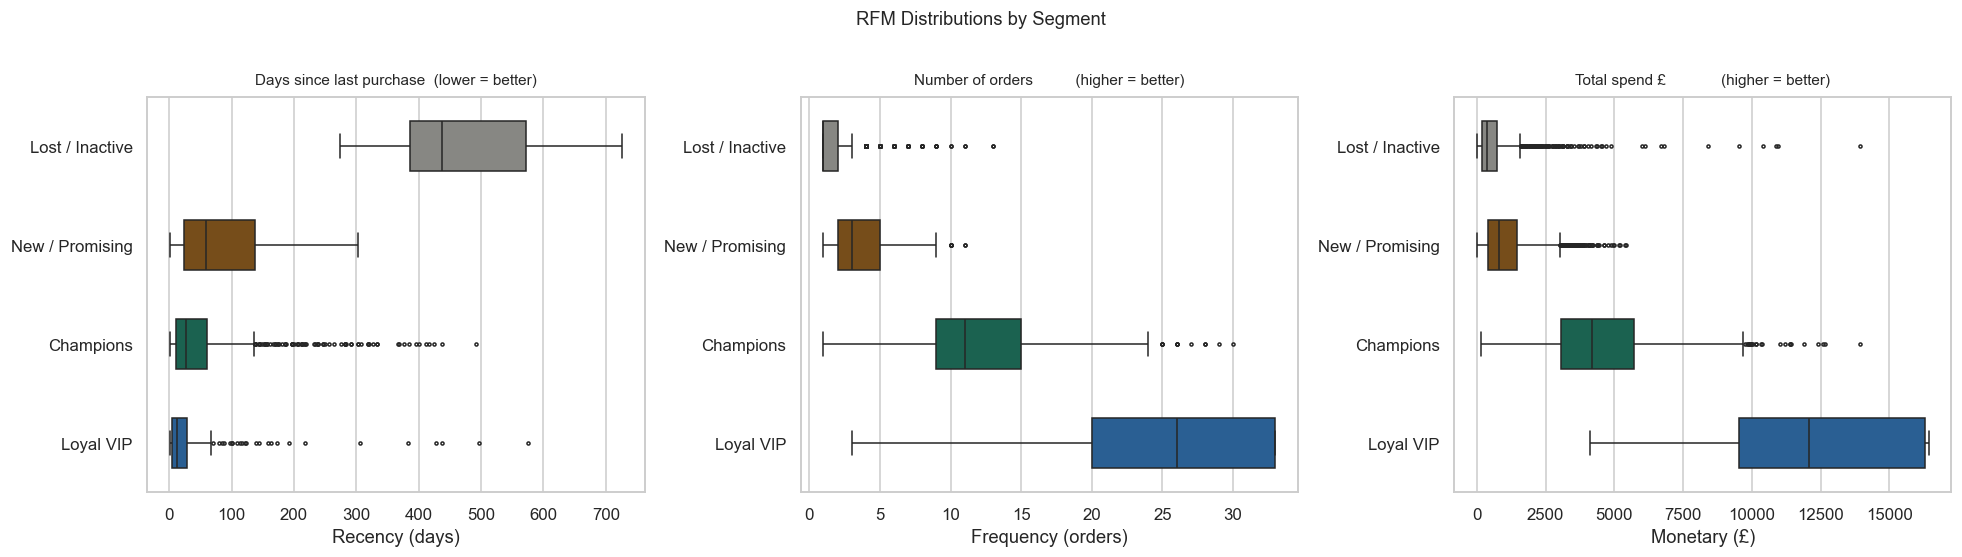

Saved → reports/plot_10_rfm_boxplots_2.png for better interpretation of Loyal VIP segment, quantile(0.95) changed to quantile(0.99)


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RFM Distributions by Segment', fontsize=12, y=1.01)

metrics = [
    ('Recency',   'Days since last purchase  (lower = better)', 'days'),
    ('Frequency', 'Number of orders          (higher = better)', 'orders'),
    ('Monetary',  'Total spend £             (higher = better)', '£'),
]

# Determine segment order by median Recency (Lost first, Champions last)
seg_order = (df.groupby('KMeans_Segment')['Recency']
               .median()
               .sort_values(ascending=False)
               .index.tolist())

for ax, (col, title, unit) in zip(axes, metrics):
    cap = df[col].quantile(0.99)
    plot_df = df.copy()
    plot_df[col] = plot_df[col].clip(upper=cap)

    palette = {s: SEGMENT_COLOURS.get(s, '#888882') for s in seg_order}
    sns.boxplot(
        data=plot_df,
        x=col, y='KMeans_Segment',
        order=seg_order,
        palette=palette,
        width=0.5,
        fliersize=2,
        ax=ax
    )
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel(f'{col} ({unit})')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_10_rfm_boxplots_2.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_10_rfm_boxplots_2.png for better interpretation of Loyal VIP segment, quantile(0.95) changed to quantile(0.99)')


## Cell 5 — 2D scatter: Recency vs Frequency
The two most important RFM dimensions plotted together.
Well-separated clusters appear as distinct colour blobs.
Overlap is normal — customers near boundaries are genuinely ambiguous.

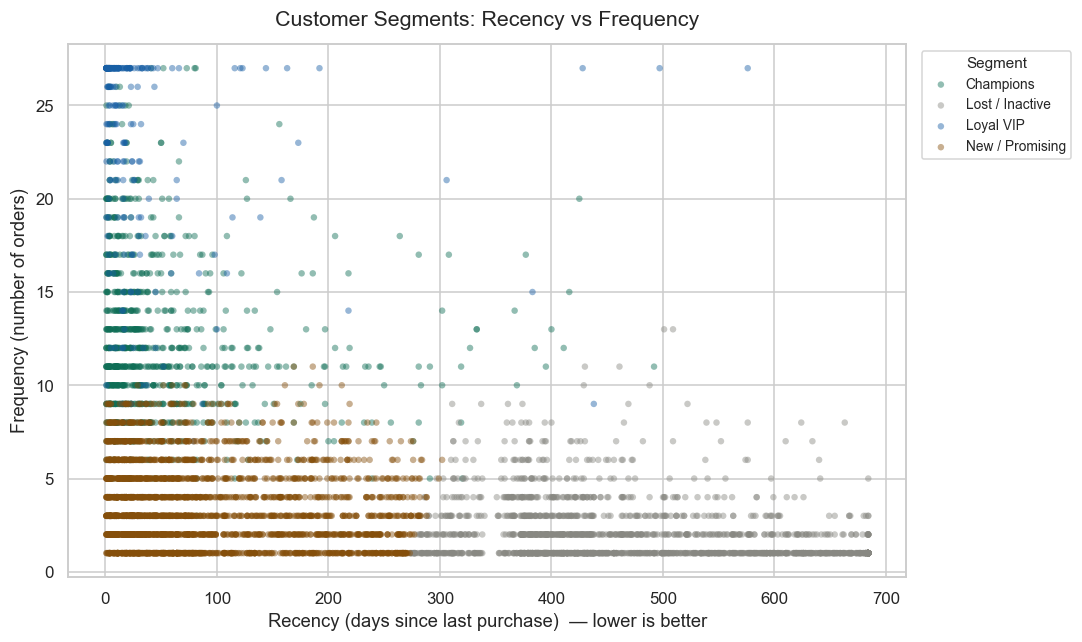

Saved → reports/plot_11_scatter_r_vs_f.png


In [22]:
# Cap extreme values so the bulk of the data is visible
plot_df = df.copy()
plot_df['Recency']   = plot_df['Recency'].clip(upper=df['Recency'].quantile(0.98))
plot_df['Frequency'] = plot_df['Frequency'].clip(upper=df['Frequency'].quantile(0.98))

fig, ax = plt.subplots(figsize=(10, 6))

for seg, grp in plot_df.groupby('KMeans_Segment'):
    ax.scatter(
        grp['Recency'], grp['Frequency'],
        c=SEGMENT_COLOURS.get(seg, '#888882'),
        label=seg,
        alpha=0.45,
        s=18,
        edgecolors='none'
    )

ax.set_title('Customer Segments: Recency vs Frequency', fontsize=14, pad=12)
ax.set_xlabel('Recency (days since last purchase)  — lower is better')
ax.set_ylabel('Frequency (number of orders)')
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_11_scatter_r_vs_f.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_11_scatter_r_vs_f.png')

## Cell 6 — Interactive 3D scatter: R vs F vs M (Plotly)
A 3D interactive chart — you can rotate, zoom, and hover.
This is the most impressive visualisation for a portfolio demo.
It shows all three RFM dimensions at once.

Tip: in your Streamlit app, embed this chart as a plotly figure.

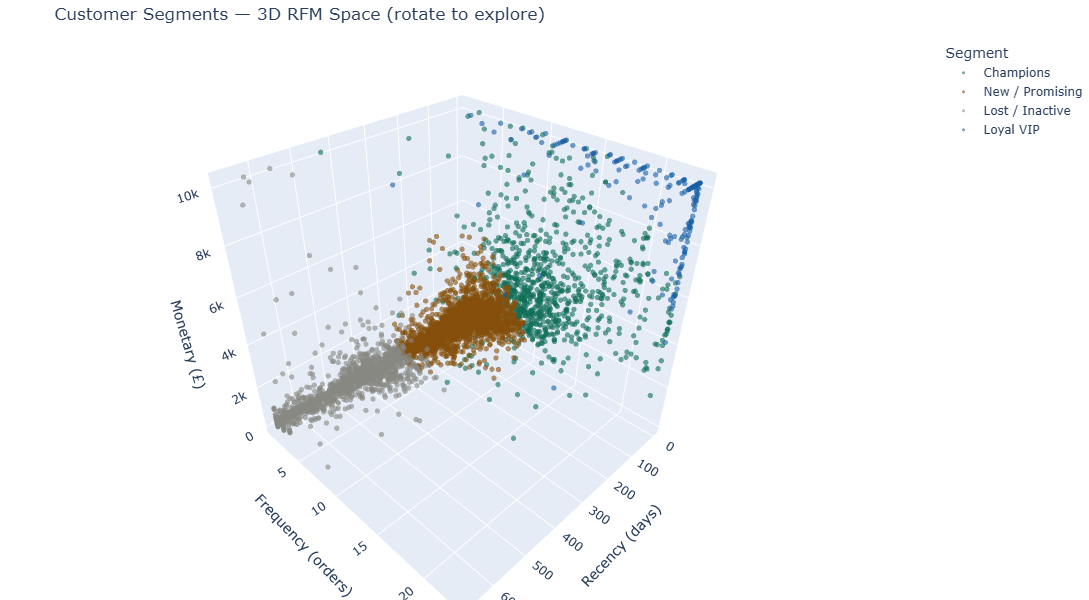

Saved interactive 3D chart → C:\Users\aishw\Documents\customer_segmentation\reports\plot_12_3d_rfm.html
Open this HTML file in a browser to interact with the chart.


In [23]:
# Cap extremes for cleaner visualisation
plot_df = df.copy()
for col in ['Recency', 'Frequency', 'Monetary']:
    plot_df[col] = plot_df[col].clip(upper=df[col].quantile(0.97))

fig_3d = px.scatter_3d(
    plot_df,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='KMeans_Segment',
    color_discrete_map=SEGMENT_COLOURS,
    hover_data={'Customer ID': True,
                'R_Score': True,
                'F_Score': True,
                'M_Score': True,
                'CLV_capped': ':.0f'},
    opacity=0.6,
    title='Customer Segments — 3D RFM Space (rotate to explore)',
    labels={
        'Recency'  : 'Recency (days)',
        'Frequency': 'Frequency (orders)',
        'Monetary' : 'Monetary (£)',
    }
)

fig_3d.update_traces(marker=dict(size=3))
fig_3d.update_layout(
    legend_title_text='Segment',
    margin=dict(l=0, r=0, t=40, b=0),
    height=600
)
fig_3d.show()

# Save as interactive HTML — can be embedded in portfolio website
out_html = RPT_DIR / 'plot_12_3d_rfm.html'
fig_3d.write_html(str(out_html))
print(f'Saved interactive 3D chart → {out_html}')
print('Open this HTML file in a browser to interact with the chart.')

## Cell 7 — Radar chart: average RFM profile per segment
A radar (spider) chart shows the RFM fingerprint of each segment on one chart.
Each axis is a normalised score (0-1). This is the clearest way to
communicate segment differences to a non-technical audience.

Champions: large area across all axes.
Lost/Inactive: small area, skewed toward high Recency (bad).

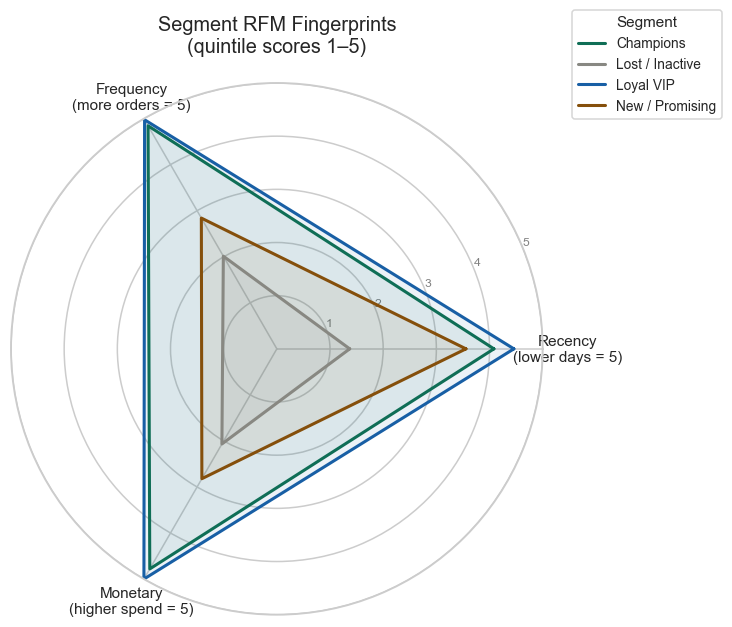

Saved → reports/plot_13_radar_segments.png


In [24]:
from matplotlib.patches import FancyArrowPatch

# Use the 1-5 quintile scores for the radar — already normalised
# Recency score is already inverted (5 = bought recently = good)
radar_cols = ['R_Score', 'F_Score', 'M_Score']
radar_labels = ['Recency\n(lower days = 5)', 'Frequency\n(more orders = 5)',
                'Monetary\n(higher spend = 5)']

seg_profiles = df.groupby('KMeans_Segment')[radar_cols].mean()

# Radar setup
N      = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(7, 7),
                       subplot_kw=dict(polar=True))

for seg, row in seg_profiles.iterrows():
    values = row.tolist() + row.tolist()[:1]  # close the polygon
    colour = SEGMENT_COLOURS.get(seg, '#888882')
    ax.plot(angles, values, linewidth=2, label=seg, color=colour)
    ax.fill(angles, values, alpha=0.08, color=colour)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=8,
                   color='gray')
ax.set_title('Segment RFM Fingerprints\n(quintile scores 1–5)',
             fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          fontsize=9, title='Segment', title_fontsize=10)

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_13_radar_segments.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_13_radar_segments.png')

## Cell 8 — CLV by segment
Which segments are worth the most to the business over their lifetime?
This directly informs marketing budget allocation:
spend most on retaining Champions and Loyal VIPs.

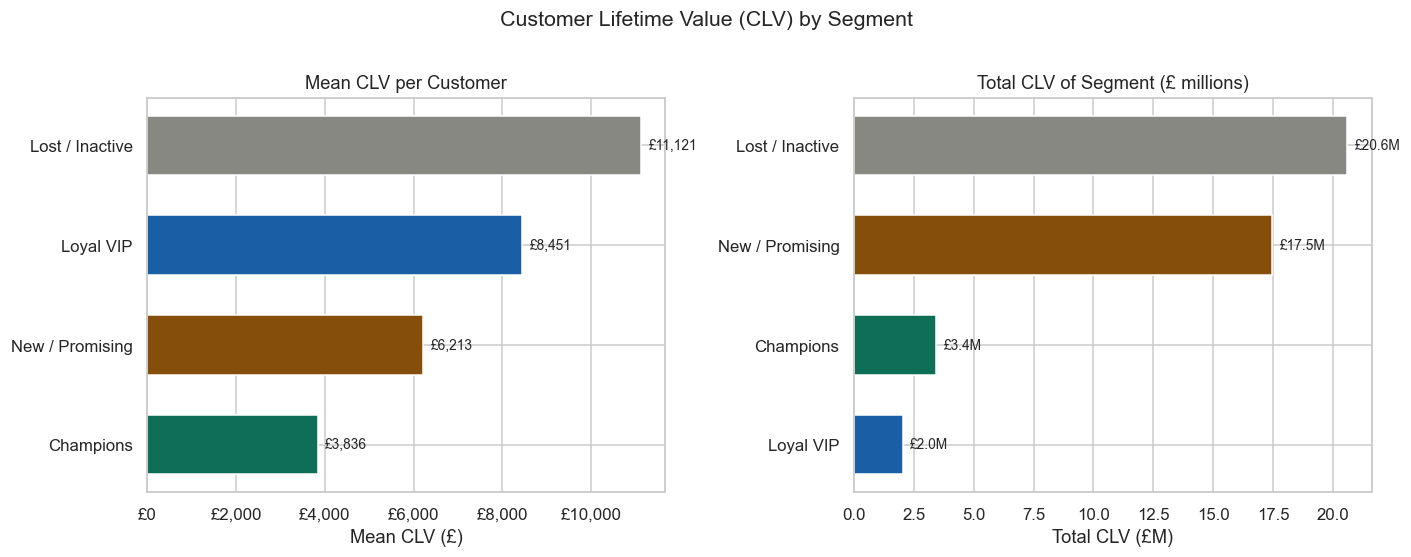

Saved → reports/plot_14_clv_by_segment.png

CLV summary by segment:
                  Mean £  Median £     Total £
KMeans_Segment                                
Champions         3836.0    2711.0   3429665.0
New / Promising   6213.0    1711.0  17459912.0
Loyal VIP         8451.0    6905.0   2028186.0
Lost / Inactive  11121.0    6686.0  20595425.0


In [25]:
clv_by_seg = (df.groupby('KMeans_Segment')['CLV_capped']
                .agg(['mean', 'median', 'sum'])
                .round(0)
                .sort_values('mean', ascending=True))

colours = [SEGMENT_COLOURS.get(s, '#888882') for s in clv_by_seg.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Customer Lifetime Value (CLV) by Segment', fontsize=14, y=1.01)

# Left: mean CLV per segment
bars = axes[0].barh(clv_by_seg.index, clv_by_seg['mean'],
                    color=colours, edgecolor='white', height=0.6)
axes[0].bar_label(bars,
                  labels=[f'£{v:,.0f}' for v in clv_by_seg['mean']],
                  padding=5, fontsize=9)
axes[0].set_title('Mean CLV per Customer')
axes[0].set_xlabel('Mean CLV (£)')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Right: total CLV per segment (business value of each group)
total_clv = (df.groupby('KMeans_Segment')['CLV_capped']
               .sum()
               .sort_values(ascending=True))
colours2 = [SEGMENT_COLOURS.get(s, '#888882') for s in total_clv.index]
bars2 = axes[1].barh(total_clv.index, total_clv.values / 1e6,
                     color=colours2, edgecolor='white', height=0.6)
axes[1].bar_label(bars2,
                  labels=[f'£{v/1e6:.1f}M' for v in total_clv.values],
                  padding=5, fontsize=9)
axes[1].set_title('Total CLV of Segment (£ millions)')
axes[1].set_xlabel('Total CLV (£M)')

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_14_clv_by_segment.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_14_clv_by_segment.png')

print('\nCLV summary by segment:')
print(clv_by_seg.rename(columns={'mean':'Mean £','median':'Median £',
                                  'sum':'Total £'}).to_string())

## Cell 9 — Segment profile summary table
A single table summarising every segment on all key dimensions.
This is what you'd present to a business stakeholder or include in a README.

In [26]:
summary = df.groupby('KMeans_Segment').agg(
    Customers    = ('Customer ID',  'count'),
    Pct          = ('Customer ID',  lambda x: f"{len(x)/len(df)*100:.1f}%"),
    Avg_Recency  = ('Recency',      'mean'),
    Avg_Frequency= ('Frequency',    'mean'),
    Avg_Monetary = ('Monetary',     'mean'),
    Avg_R_Score  = ('R_Score',      'mean'),
    Avg_F_Score  = ('F_Score',      'mean'),
    Avg_M_Score  = ('M_Score',      'mean'),
    Avg_CLV      = ('CLV_capped',   'mean'),
).round(1).sort_values('Customers', ascending=False)

print('Full segment profile summary:')
print(summary.to_string())

# Business interpretation printed below each segment
interpretations = {
    'Loyal VIP'       : 'Your most valuable customers. High frequency, high spend, bought recently. Nurture with VIP perks and early access.',
    'Champions'       : 'Strong, active customers. Bought recently and frequently. Reward them — they are your word-of-mouth engine.',
    'New / Promising' : 'Recently acquired but not yet loyal. Low frequency, low spend. Convert with a second-purchase incentive.',
    'At Risk'         : 'Were loyal but starting to lapse. Act fast with a re-engagement campaign before they become Lost.',
    'Needs Attention' : 'Mixed signals — some recency, inconsistent frequency. Need personalised outreach to understand their needs.',
    'Lost / Inactive' : 'Have not purchased in a long time. Low frequency, low spend. Win-back campaigns for this group have low ROI.',
}

print('\n── Business interpretations ──────────────────────────────')
for seg, text in interpretations.items():
    if seg in df['KMeans_Segment'].unique():
        count = (df['KMeans_Segment'] == seg).sum()
        print(f'\n  {seg} ({count:,} customers)')
        print(f'  {text}')

Full segment profile summary:
                 Customers    Pct  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_R_Score  Avg_F_Score  Avg_M_Score  Avg_CLV
KMeans_Segment                                                                                                             
New / Promising       2810  48.5%         86.8            3.4        1043.4          3.6          2.8          2.8   6213.5
Lost / Inactive       1852  32.0%        476.5            2.0         632.8          1.4          2.0          2.1  11120.6
Champions              894  15.4%         51.3           12.3        4609.4          4.1          4.8          4.8   3836.3
Loyal VIP              240   4.1%         34.1           26.1       13332.8          4.5          5.0          5.0   8450.8

── Business interpretations ──────────────────────────────

  Loyal VIP (240 customers)
  Your most valuable customers. High frequency, high spend, bought recently. Nurture with VIP perks and early access.

  Champions (894 c

## Cell 10 — K-Medoids comparison (Approach B)
Run K-Medoids on the FULL dataset (including outliers) to confirm that
the bulk B2B accounts are a genuinely distinct customer type.
This validates our decision to separate them before K-Means clustering.

Install first if needed: `pip install scikit-learn-extra`

In [7]:
pip uninstall scikit-learn-extra -y

Found existing installation: scikit-learn-extra 0.3.0
Uninstalling scikit-learn-extra-0.3.0:
  Successfully uninstalled scikit-learn-extra-0.3.0
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


In [8]:
pip install scikit-learn-extra --no-cache-dir

Note: you may need to restart the kernel to use updated packages.


In [1]:
import joblib

try:
    from sklearn_extra.cluster import KMedoids
    KMEDOIDS_AVAILABLE = True
except ImportError:
    KMEDOIDS_AVAILABLE = False
    print('scikit-learn-extra not installed.')
    print('Run: pip install scikit-learn-extra')
    print('Then restart the kernel and rerun this cell.')

if KMEDOIDS_AVAILABLE:
    # Load full dataset (including outliers) and the saved scaler
    df_full  = pd.read_csv(ROOT / 'data' / 'rfm_full.csv')
    scaler   = joblib.load(ROOT / 'data' / 'scaler.joblib')

    # Transform using the SAME scaler (not refit) for fair comparison
    FEATURES = ['Recency', 'Frequency', 'Monetary']
    X_full   = scaler.transform(df_full[FEATURES])

    # Fit K-Medoids with k=4 for direct comparison with K-Means
    km_med = KMedoids(n_clusters=4, metric='euclidean', random_state=42)
    df_full['KMedoids_Cluster'] = km_med.fit_predict(X_full)

    print('K-Medoids cluster sizes (full dataset including outliers):')
    print(df_full['KMedoids_Cluster'].value_counts().sort_index())

    print('\nK-Medoids cluster profiles (unscaled averages):')
    print(df_full.groupby('KMedoids_Cluster')[FEATURES].mean().round(1).to_string())

    print('\nObservation:')
    print('If 1-2 clusters are dominated by very high Monetary/Frequency,')
    print('that confirms the bulk B2B accounts form a structurally distinct')
    print('customer type — validating our outlier separation approach.')

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [6]:
# K-Medoids approximation using sklearn only
# Real K-Medoids finds actual data points as centres.
# We approximate by: run K-Means, then for each cluster
# find the real customer closest to the computed centre.
# This gives us the "medoid" — the most representative real customer.

import joblib
import numpy as np

df_full = pd.read_csv(ROOT / 'data' / 'rfm_full.csv')
scaler  = joblib.load(ROOT / 'data' / 'scaler.joblib')

FEATURES = ['Recency', 'Frequency', 'Monetary']
X_full   = scaler.transform(df_full[FEATURES])

# Run K-Means on full dataset (including outliers)
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

km_full = KMeans(n_clusters=4, n_init=10, random_state=42)
km_full.fit(X_full)
df_full['Cluster'] = km_full.labels_

# Find the medoid: real customer closest to each cluster centre
print('K-Means on full dataset (including outliers):')
print('\nCluster sizes:')
print(df_full['Cluster'].value_counts().sort_index())

print('\nCluster profiles (unscaled averages):')
print(df_full.groupby('Cluster')[FEATURES].mean().round(1).to_string())

print('\nMedoid customers (most representative real customer per cluster):')
for cluster_id in sorted(df_full['Cluster'].unique()):
    mask    = df_full['Cluster'] == cluster_id
    X_clust = X_full[mask]
    centre  = km_full.cluster_centers_[cluster_id].reshape(1, -1)

    # Distance from every customer in this cluster to the centre
    dists   = pairwise_distances(X_clust, centre).flatten()
    medoid_idx = dists.argmin()
    medoid_row = df_full[mask].iloc[medoid_idx]

    print(f'\n  Cluster {cluster_id} medoid — Customer {medoid_row["Customer ID"]}:')
    print(f'    Recency  : {medoid_row["Recency"]:.0f} days')
    print(f'    Frequency: {medoid_row["Frequency"]:.0f} orders')
    print(f'    Monetary : £{medoid_row["Monetary"]:,.0f}')

print('\nObservation:')
print('If 1-2 clusters show extreme Monetary/Frequency values,')
print('the bulk B2B accounts are confirmed as a structurally')
print('distinct customer type — validating our outlier separation.')

K-Means on full dataset (including outliers):

Cluster sizes:
Cluster
0     199
1      13
2    5664
3       2
Name: count, dtype: int64

Cluster profiles (unscaled averages):
         Recency  Frequency  Monetary
Cluster                              
0           40.4       41.5   23475.9
1            7.9      127.4  174410.8
2          207.5        4.7    1646.6
3            1.5      148.0  554794.8

Medoid customers (most representative real customer per cluster):

  Cluster 0 medoid — Customer 15498.0:
    Recency  : 3 days
    Frequency: 44 orders
    Monetary : £24,973

  Cluster 1 medoid — Customer 13694.0:
    Recency  : 4 days
    Frequency: 143 orders
    Monetary : £195,641

  Cluster 2 medoid — Customer 15381.0:
    Recency  : 214 days
    Frequency: 5 orders
    Monetary : £1,891

  Cluster 3 medoid — Customer 14646.0:
    Recency  : 2 days
    Frequency: 151 orders
    Monetary : £528,603

Observation:
If 1-2 clusters show extreme Monetary/Frequency values,
the bulk B2B acc

## Cell 11 — Git commit
Save all Week 2 work to Git.

In [5]:
print('Week 2 complete! Run these commands in your terminal:\n')
print('  git add src/features.py src/train.py notebooks/02_rfm_clustering.ipynb reports/')
print('  git commit -m "Week 2: RFM scoring, K-Means clustering, segment profiles"')
print('  git push')
print()
print('Files produced this week:')
for f in [
    'data/rfm_scores.csv',
    'data/rfm_segments.csv',
    'data/vip_outliers.csv',
    'data/scaler.joblib',
    'data/kmeans_model.joblib',
    'reports/plot_08_kmeans_evaluation.png',
    'reports/plot_09_segment_sizes.png',
    'reports/plot_10_rfm_boxplots.png',
    'reports/plot_11_scatter_r_vs_f.png',
    'reports/plot_12_3d_rfm.html',
    'reports/plot_13_radar_segments.png',
    'reports/plot_14_clv_by_segment.png',
]:
    exists = '✓' if (ROOT / f).exists() else '✗  (missing)'
    print(f'  {exists}  {f}')

print()
print('Next → Week 3: Cohort retention analysis + churn prediction model')

Week 2 complete! Run these commands in your terminal:

  git add src/features.py src/train.py notebooks/02_rfm_clustering.ipynb reports/
  git commit -m "Week 2: RFM scoring, K-Means clustering, segment profiles"
  git push

Files produced this week:
  ✓  data/rfm_scores.csv
  ✓  data/rfm_segments.csv
  ✓  data/vip_outliers.csv
  ✓  data/scaler.joblib
  ✓  data/kmeans_model.joblib
  ✓  reports/plot_08_kmeans_evaluation.png
  ✓  reports/plot_09_segment_sizes.png
  ✓  reports/plot_10_rfm_boxplots.png
  ✓  reports/plot_11_scatter_r_vs_f.png
  ✓  reports/plot_12_3d_rfm.html
  ✓  reports/plot_13_radar_segments.png
  ✓  reports/plot_14_clv_by_segment.png

Next → Week 3: Cohort retention analysis + churn prediction model
